In [74]:
# importing necessary library
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error,mean_absolute_error,r2_score
from sklearn.model_selection import train_test_split

In [75]:
#load the dataset
df=pd.read_csv('Lab 21 House_rent_Dataset.csv')
df.head() # top 5 rows

,Posted On,BHK,Rent,Size,Floor,Area Type,Area Locality,City,Furnishing Status,Tenant Preferred,Bathroom,Point of Contact
0,2022-05-18,2,10000,1100,Ground out of 2,Super Area,Bandel,Kolkata,Unfurnished,Bachelors/Family,2,Contact Owner
1,2022-05-13,2,20000,800,1 out of 3,Super Area,"Phool Bagan, Kankurgachi",Kolkata,Semi-Furnished,Bachelors/Family,1,Contact Owner
2,2022-05-16,2,17000,1000,1 out of 3,Super Area,Salt Lake City Sector 2,Kolkata,Semi-Furnished,Bachelors/Family,1,Contact Owner
3,2022-07-04,2,10000,800,1 out of 2,Super Area,Dumdum Park,Kolkata,Unfurnished,Bachelors/Family,1,Contact Owner
4,2022-05-09,2,7500,850,1 out of 2,Carpet Area,South Dum Dum,Kolkata,Unfurnished,Bachelors,1,Contact Owner


In [76]:
# rows & cols 
df.shape

(4746, 12)

In [77]:
# info of the dataset
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 4746 entries, 0 to 4745
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype
---  ------             --------------  -----
 0   Posted On          4746 non-null   str  
 1   BHK                4746 non-null   int64
 2   Rent               4746 non-null   int64
 3   Size               4746 non-null   int64
 4   Floor              4746 non-null   str  
 5   Area Type          4746 non-null   str  
 6   Area Locality      4746 non-null   str  
 7   City               4746 non-null   str  
 8   Furnishing Status  4746 non-null   str  
 9   Tenant Preferred   4746 non-null   str  
 10  Bathroom           4746 non-null   int64
 11  Point of Contact   4746 non-null   str  
dtypes: int64(4), str(8)
memory usage: 445.1 KB


In [78]:
#cols
df.columns

Index(['Posted On', 'BHK', 'Rent', 'Size', 'Floor', 'Area Type',
       'Area Locality', 'City', 'Furnishing Status', 'Tenant Preferred',
       'Bathroom', 'Point of Contact'],
      dtype='str')

In [79]:
df.describe()

,BHK,Rent,Size,Bathroom
count,4746.000000,4.746000e+03,4746.000000,4746.000000
mean,2.083860,3.499345e+04,967.490729,1.965866
std,0.832256,7.810641e+04,634.202328,0.884532
min,1.000000,1.200000e+03,10.000000,1.000000
25%,2.000000,1.000000e+04,550.000000,1.000000
50%,2.000000,1.600000e+04,850.000000,2.000000
75%,3.000000,3.300000e+04,1200.000000,2.000000
max,6.000000,3.500000e+06,8000.000000,10.000000


<Axes: >

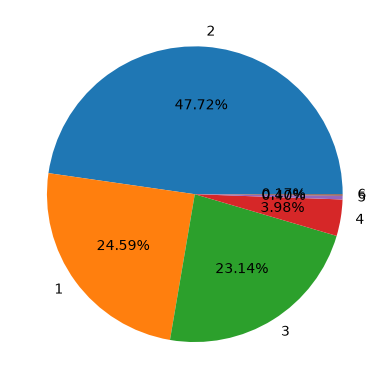

In [80]:
#visualize
df['BHK'].value_counts().plot(kind='pie',autopct='%1.2f%%')

In [81]:
df['BHK'].value_counts().sort_values()

BHK
6       8
5      19
4     189
3    1098
1    1167
2    2265
Name: count, dtype: int64

In [82]:
df['City'].unique()

<StringArray>
['Kolkata', 'Mumbai', 'Bangalore', 'Delhi', 'Chennai', 'Hyderabad']
Length: 6, dtype: str

In [83]:
df['Point of Contact'].unique()

<StringArray>
['Contact Owner', 'Contact Agent', 'Contact Builder']
Length: 3, dtype: str

In [84]:
df = df.drop(['Posted On','Floor','Area Locality'],axis=1,errors='ignore')
df.head(3)

,BHK,Rent,Size,Area Type,City,Furnishing Status,Tenant Preferred,Bathroom,Point of Contact
0,2,10000,1100,Super Area,Kolkata,Unfurnished,Bachelors/Family,2,Contact Owner
1,2,20000,800,Super Area,Kolkata,Semi-Furnished,Bachelors/Family,1,Contact Owner
2,2,17000,1000,Super Area,Kolkata,Semi-Furnished,Bachelors/Family,1,Contact Owner


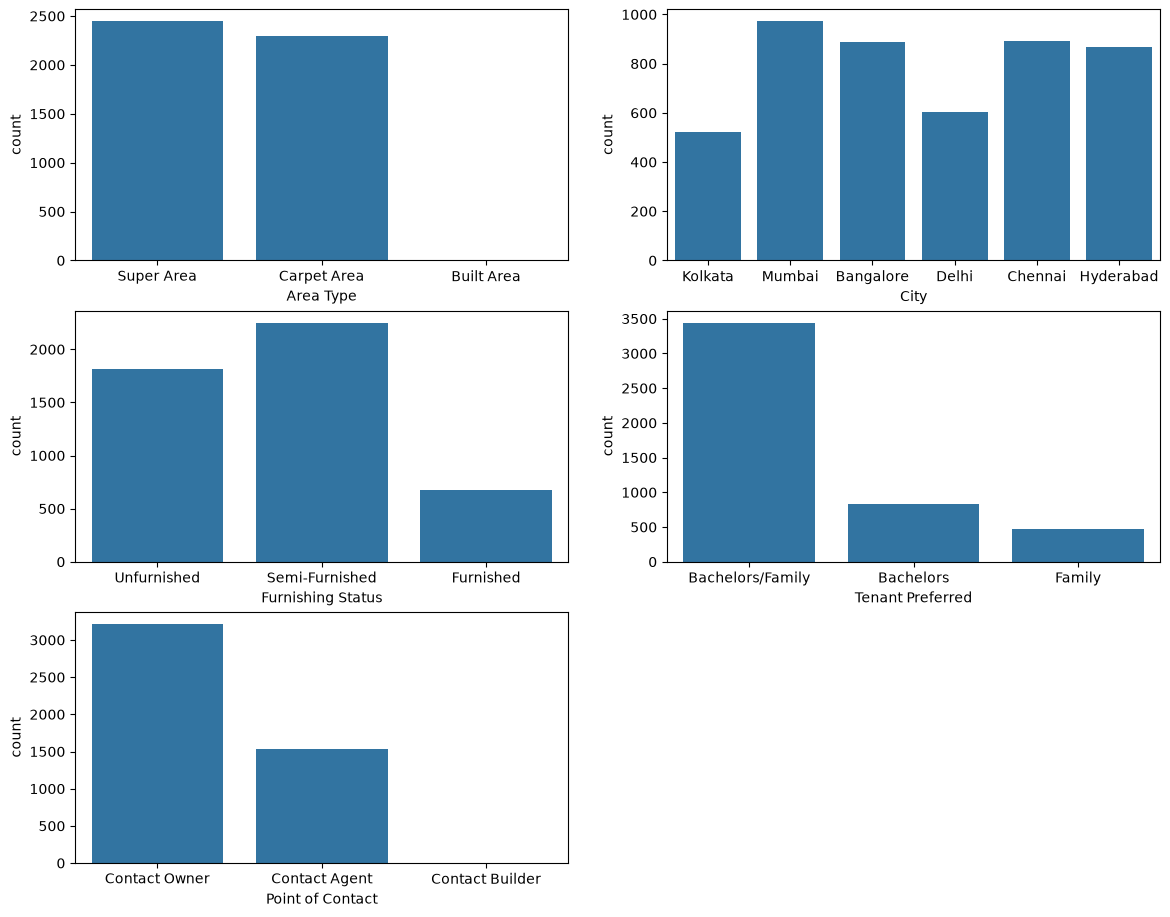

In [85]:
plt.figure(figsize=(14,15))
for i,col in enumerate(["Area Type","City","Furnishing Status","Tenant Preferred","Point of Contact"]):
    plt.subplot(4,2,i+1)
    sns.countplot(data=df,x=col)

In [86]:
!pip install category-encoders


[notice] A new release of pip is available: 24.3.1 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


Text(0.5, 1.0, 'Relation between rent and BHK by city')

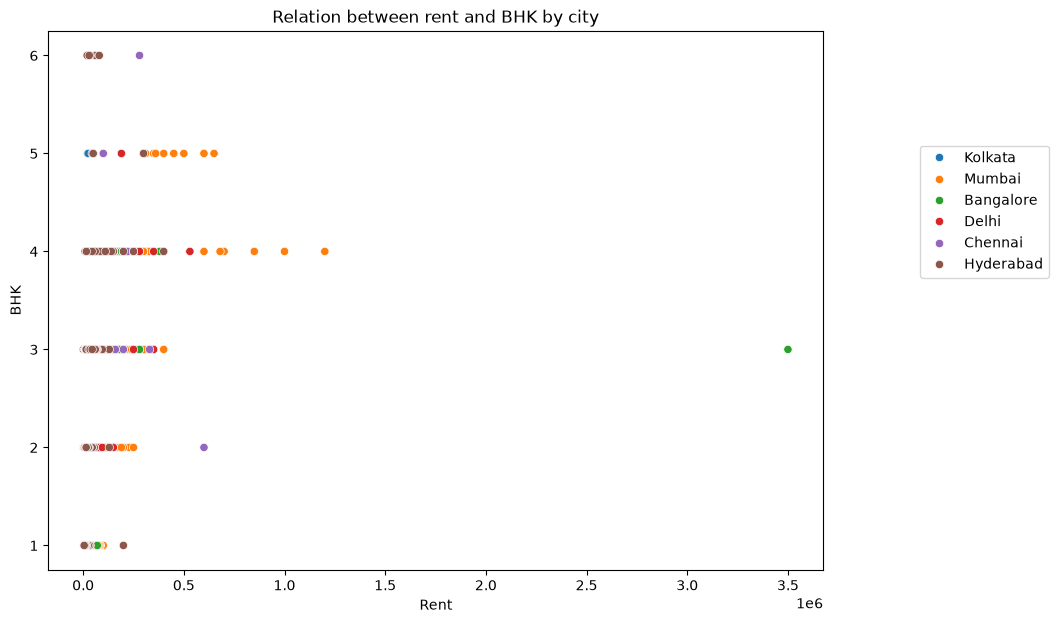

In [87]:
plt.figure(figsize=(10,7))
sns.scatterplot(x='Rent',y='BHK',data=df,hue='City')
plt.legend(bbox_to_anchor=(1.3,0.8))
plt.title('Relation between rent and BHK by city')

<Axes: xlabel='Rent', ylabel='Size'>

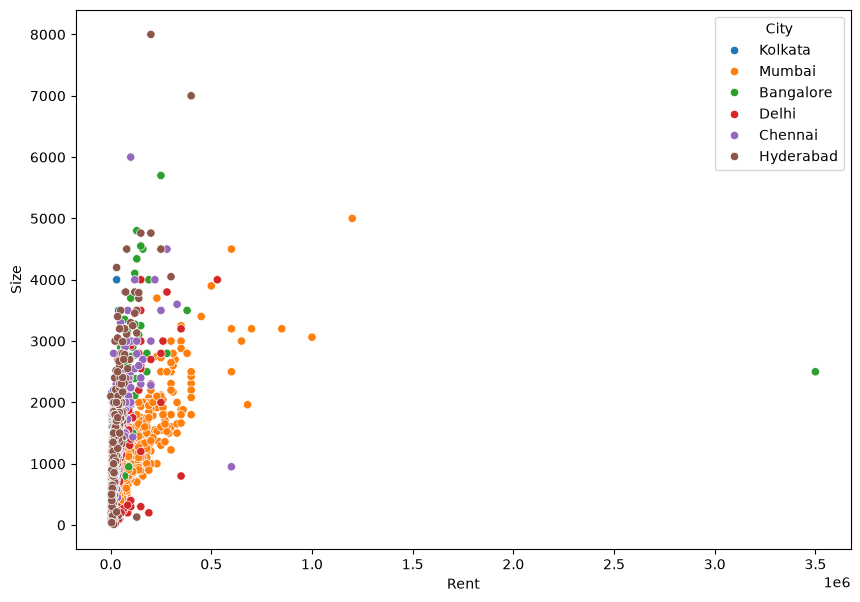

In [88]:
plt.figure(figsize=(10,7))
sns.scatterplot(data=df,x='Rent',y='Size',hue='City')

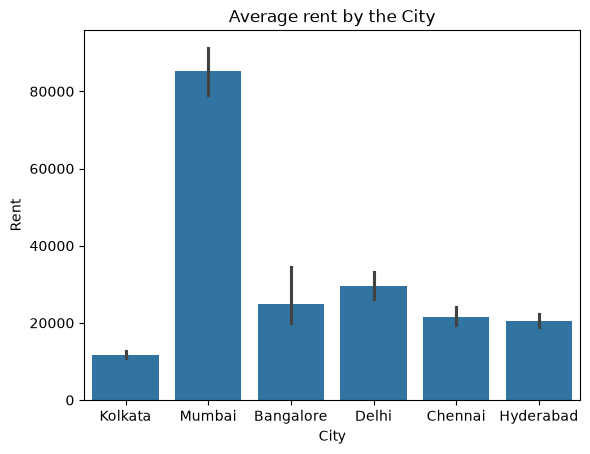

In [89]:
sns.barplot(data=df,x='City',y='Rent')
plt.title('Average rent by the City')
plt.show()

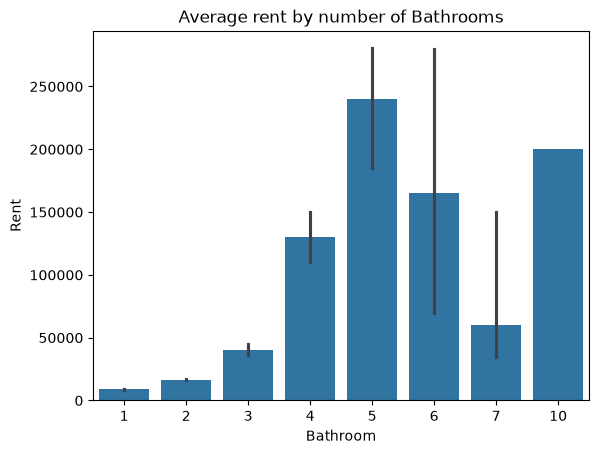

In [90]:
sns.barplot(data=df,x='Bathroom',y='Rent',estimator=np.median)
plt.title('Average rent by number of Bathrooms')
plt.show()

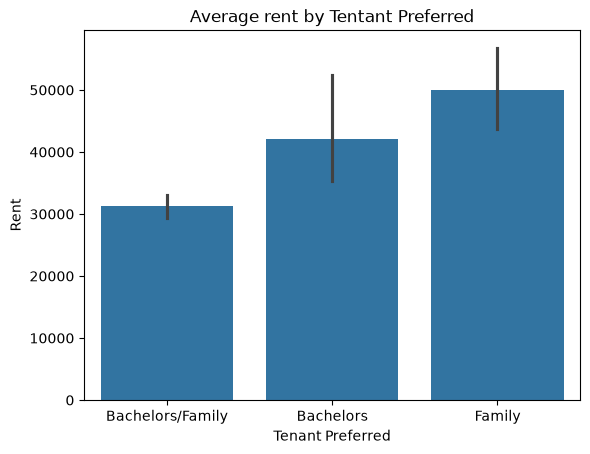

In [91]:
sns.barplot(data=df,x ='Tenant Preferred',y='Rent')
plt.title('Average rent by Tentant Preferred')
plt.show()

In [92]:
# encoding - categ -> numer var
import category_encoders as ce
enc=ce.LeaveOneOutEncoder(return_df=True)

In [93]:
df.head()

,BHK,Rent,Size,Area Type,City,Furnishing Status,Tenant Preferred,Bathroom,Point of Contact
0,2,10000,1100,Super Area,Kolkata,Unfurnished,Bachelors/Family,2,Contact Owner
1,2,20000,800,Super Area,Kolkata,Semi-Furnished,Bachelors/Family,1,Contact Owner
2,2,17000,1000,Super Area,Kolkata,Semi-Furnished,Bachelors/Family,1,Contact Owner
3,2,10000,800,Super Area,Kolkata,Unfurnished,Bachelors/Family,1,Contact Owner
4,2,7500,850,Carpet Area,Kolkata,Unfurnished,Bachelors,1,Contact Owner


In [97]:
x=df.drop('Rent',axis=1)
y=df['Rent']

In [100]:
x=enc.fit_transform(x,y)

In [101]:
x.head()

,BHK,Size,Area Type,City,Furnishing Status,Tenant Preferred,Bathroom,Point of Contact
0,2,1100,18676.943967,11648.319312,22468.505513,31216.953238,2,16706.291757
1,2,800,18672.853988,11629.198853,38727.130222,31214.048795,1,16703.181337
2,2,1000,18674.080982,11634.934990,38728.463556,31214.920128,1,16704.114463
3,2,800,18676.943967,11648.319312,22468.505513,31216.953238,1,16706.291757
4,2,850,52405.438398,11653.099426,22469.883682,42185.583836,1,16707.069362


In [105]:
#scaling:
from sklearn.preprocessing import MinMaxScaler
scaler=MinMaxScaler()

In [114]:
x=scaler.fit_transfrom(x)

AttributeError: 'MinMaxScaler' object has no attribute 'fit_transfrom'

In [109]:
x_df=pd.DataFrame(x)
x_df.head()

,BHK,Size,Area Type,City,Furnishing Status,Tenant Preferred,Bathroom,Point of Contact
0,2,1100,18676.943967,11648.319312,22468.505513,31216.953238,2,16706.291757
1,2,800,18672.853988,11629.198853,38727.130222,31214.048795,1,16703.181337
2,2,1000,18674.080982,11634.934990,38728.463556,31214.920128,1,16704.114463
3,2,800,18676.943967,11648.319312,22468.505513,31216.953238,1,16706.291757
4,2,850,52405.438398,11653.099426,22469.883682,42185.583836,1,16707.069362


In [110]:
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.svm import SVR

In [112]:
# splitting dataset
x_train,x_test,y_train,y_test=train_test_split(x,y,
                                      train_size=0.8,
                                      random_state=42)

In [116]:
x_train.shape,x_test.shape

((3796, 8), (950, 8))

In [117]:
lr=LinearRegression()
lr.fit(x_train,y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](8,)","[5525.65, 34.54, 0.18,..., -0.56,9124.86, 0.21]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](8,)","['BHK','Size','Area Type',...,'Tenant Preferred','Bathroom', 'Point of Contact']"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,-5.587e+04
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,8
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(8)


In [119]:
y_pred =lr.predict(x_test)

In [120]:
mse= mean_squared_error(y_test,y_pred)
mse

1931480573.9933295

In [121]:
mae = mean_absolute_error(y_test,y_pred)
mae

22537.864304351002

In [122]:
r2=r2_score(y_test,y_pred)
r2

0.5153586519637426

In [124]:
#dtr
dtr=DecisionTreeRegressor()
dtr.fit(x_train,y_train)
dtr_pred=dtr.predict(x_test)
dtr_r2 = r2_score(y_test,dtr_pred)
dtr_r2*100

93.49876476001103

In [125]:
#rfr
rfr= RandomForestRegressor()
rfr.fit(x_train,y_train)
rfr_pred=rfr.predict(x_test)
rfr_r2=r2_score(y_test,rfr_pred)
rfr_r2*100

93.85440463484295

In [126]:
#svm
svr = SVR()
svr.fit(x_train,y_train)
svr_pred=svr.predict(x_test)
svr_r2=r2_score(y_test,svr_pred)
svr_r2*100

-7.568416187322624

# classification model

In [1]:
# importing necessary libraries
import pandas as pd
import numpy as np
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score,precision_score,recall_score

In [2]:
#load the dataset
wdf=pd.read_csv('Lab 22 winequality-red.csv')
wdf.head()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5


In [3]:
wdf.describe()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
count,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000
mean,8.319637,0.527821,0.270976,2.538806,0.087467,15.874922,46.467792,0.996747,3.311113,0.658149,10.422983,5.636023
std,1.741096,0.179060,0.194801,1.409928,0.047065,10.460157,32.895324,0.001887,0.154386,0.169507,1.065668,0.807569
min,4.600000,0.120000,0.000000,0.900000,0.012000,1.000000,6.000000,0.990070,2.740000,0.330000,8.400000,3.000000
25%,7.100000,0.390000,0.090000,1.900000,0.070000,7.000000,22.000000,0.995600,3.210000,0.550000,9.500000,5.000000
50%,7.900000,0.520000,0.260000,2.200000,0.079000,14.000000,38.000000,0.996750,3.310000,0.620000,10.200000,6.000000
75%,9.200000,0.640000,0.420000,2.600000,0.090000,21.000000,62.000000,0.997835,3.400000,0.730000,11.100000,6.000000
max,15.900000,1.580000,1.000000,15.500000,0.611000,72.000000,289.000000,1.003690,4.010000,2.000000,14.900000,8.000000


In [5]:
wdf['quality'].unique()

array([5, 6, 7, 4, 8, 3])

In [6]:
wdf.columns

Index(['fixed acidity', 'volatile acidity', 'citric acid', 'residual sugar',
       'chlorides', 'free sulfur dioxide', 'total sulfur dioxide', 'density',
       'pH', 'sulphates', 'alcohol', 'quality'],
      dtype='str')

In [9]:
X=wdf.drop(columns='quality')
Y=wdf['quality']

In [10]:
X.columns

Index(['fixed acidity', 'volatile acidity', 'citric acid', 'residual sugar',
       'chlorides', 'free sulfur dioxide', 'total sulfur dioxide', 'density',
       'pH', 'sulphates', 'alcohol'],
      dtype='str')

In [11]:
Y.value_counts()

quality
5    681
6    638
7    199
4     53
8     18
3     10
Name: count, dtype: int64

In [12]:
!pip install imblearn


[notice] A new release of pip is available: 24.3.1 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [13]:
from imblearn.over_sampling import SMOTE
oversample = SMOTE(k_neighbors=4)

X,Y = oversample.fit_resample(X.fillna(0),Y)

In [14]:
Y.value_counts()

quality
5    681
6    681
7    681
4    681
8    681
3    681
Name: count, dtype: int64

In [15]:
Xtr,Xte,Ytr,Yte=train_test_split(X,Y,test_size=0.2,
                                random_state=42)

In [18]:
#log reg
lgr=LogisticRegression()
lgr.fit(Xtr,Ytr)
lgr_pred=lgr.predict(Xte)
lgr_pred

C:\Users\varsh\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\linear_model\_logistic.py:599: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


array([3, 5, 8, 6, 4, 4, 5, 3, 5, 5, 7, 7, 5, 5, 8, 6, 4, 4, 7, 6, 6, 5,
       5, 3, 5, 4, 7, 3, 6, 8, 3, 3, 7, 8, 3, 6, 4, 7, 3, 7, 8, 8, 5, 8,
       6, 4, 7, 4, 4, 7, 7, 8, 7, 6, 7, 3, 4, 7, 4, 3, 4, 4, 3, 3, 8, 4,
       4, 8, 7, 6, 3, 3, 5, 3, 4, 5, 5, 6, 6, 3, 8, 8, 6, 5, 4, 8, 8, 3,
       8, 4, 3, 6, 6, 3, 4, 6, 4, 8, 8, 8, 5, 8, 3, 5, 5, 4, 8, 4, 7, 8,
       3, 5, 8, 5, 6, 6, 5, 7, 3, 5, 5, 4, 7, 5, 5, 7, 7, 3, 3, 3, 8, 6,
       5, 3, 5, 3, 7, 5, 4, 4, 7, 5, 5, 3, 7, 7, 8, 4, 7, 4, 4, 5, 4, 5,
       5, 3, 3, 8, 8, 8, 4, 4, 7, 6, 8, 4, 7, 6, 4, 4, 4, 8, 4, 5, 7, 7,
       4, 3, 7, 4, 3, 3, 8, 7, 7, 6, 3, 8, 6, 8, 8, 5, 6, 8, 7, 4, 4, 4,
       4, 8, 6, 8, 3, 4, 4, 7, 4, 5, 5, 3, 8, 7, 6, 5, 7, 6, 5, 3, 8, 5,
       5, 3, 8, 7, 8, 3, 5, 3, 6, 8, 6, 4, 8, 5, 5, 5, 8, 7, 5, 4, 3, 7,
       3, 4, 4, 5, 8, 6, 7, 8, 4, 7, 7, 7, 3, 4, 4, 4, 5, 6, 4, 8, 4, 8,
       7, 5, 8, 7, 8, 3, 8, 3, 4, 8, 3, 6, 5, 8, 3, 8, 5, 7, 5, 6, 5, 5,
       3, 5, 4, 7, 8, 5, 4, 5, 8, 5, 3, 5, 7, 4, 6,

In [19]:
acc = accuracy_score(Yte,lgr_pred)
acc*100

45.47677261613692

In [22]:
from sklearn.metrics import confusion_matrix,classification_report
cm=confusion_matrix(Yte,lgr_pred)
cm

array([[81, 22, 24,  5,  0,  0],
       [18, 72, 29, 10,  1,  1],
       [23, 35, 66, 18,  5,  3],
       [18, 28, 28, 39, 19, 23],
       [ 4,  6,  1, 22, 39, 44],
       [ 0,  0,  0,  3, 56, 75]])

In [23]:
cr=classification_report(Yte,lgr_pred)
print(cr)

              precision    recall  f1-score   support

           3       0.56      0.61      0.59       132
           4       0.44      0.55      0.49       131
           5       0.45      0.44      0.44       150
           6       0.40      0.25      0.31       155
           7       0.33      0.34      0.33       116
           8       0.51      0.56      0.54       134

    accuracy                           0.45       818
   macro avg       0.45      0.46      0.45       818
weighted avg       0.45      0.45      0.45       818

